### Scripts functions

In [20]:
#Organism preprocessing
import json
from collections import Counter
import pandas as pd 
def process_organism_data(df_3, json_path="Organism_names_dictionary.json",\
                          accession_no = 'Accession ID.', organism_detected = 'Organism Detected',\
                         resistance_detected = 'Resistance Detected', og_count = False):
    import warnings

    # Suppress all warnings
    warnings.filterwarnings("ignore")
    # Step 1: Drop rows where 'Accession ID.' is NaN
    df_3 = df_3.dropna(subset=['Accession ID.'])
    df_3.reset_index(drop=True, inplace=True)
    print("Step 1: Dropped rows with NaN in 'Accession ID.' and reset index.")
    print("Data shape after Step 1: ", df_3.shape)

    # Step 2: Drop duplicate rows based on ['Accession ID.', 'Organism Detected', 'Resistance Detected']
    df_3.drop_duplicates(subset=['Accession ID.', 'Organism Detected', 'Resistance Detected'], keep="first", inplace=True)
    df_3.reset_index(drop=True, inplace=True)
    print("Step 2: Dropped duplicate rows based on ['Accession ID.', 'Organism Detected', 'Resistance Detected'] and reset index.")
    print("Data shape after Step 2: ", df_3.shape)

    # Step 3: Handle null values in 'Organism Detected'
    print("Null values before in 'Organism Detected': ", df_3["Organism Detected"].isna().sum())
    df_3["Organism Detected"] = df_3["Organism Detected"].fillna("none detected")
    print("Null values after in 'Organism Detected': ", df_3["Organism Detected"].isna().sum())

    # Step 4: Make sure 'Organism Detected' is a string
    print("Step 4: Converting 'Organism Detected' column to string and performing cleanup.")
    df_3["Organism Detected"] = df_3["Organism Detected"].astype(str)

    # Step 5: Convert to lowercase and strip whitespaces
    df_3["Organism Detected"] = df_3["Organism Detected"].str.lower()
    df_3["Organism Detected"] = df_3["Organism Detected"].str.strip()
    print("Step 5: Converted 'Organism Detected' to lowercase and stripped extra spaces.")

    # Step 6: Replace commas with newline characters
    df_3["Organism Detected"] = df_3["Organism Detected"].str.replace(",", "\n")
    print("Step 6: Replaced commas with newline characters in 'Organism Detected'.")

    # Step 7: Split 'Organism Detected' into lists and remove empty entries
    df_3["Organism Detected"] = df_3["Organism Detected"].apply(
        lambda x: [org.strip() for org in str(x).split("\n") if org.strip() != '']
    )
    print("Step 7: Split 'Organism Detected' into lists and removed empty entries.")

    # Step 8: Replace 'nill' with 'none detected' in the lists
    df_3["Organism Detected"] = df_3["Organism Detected"].apply(
        lambda x: ["none detected" if org == "nill" else org for org in x] if isinstance(x, list) else x
    )
    df_3["Organism Detected"] = df_3["Organism Detected"].replace("nill", "none detected")
    print("Step 8: Replaced 'nill' with 'none detected' in 'Organism Detected'.")

    # Step 9: Load the organism name dictionary from a JSON file
    with open(json_path, "r") as json_file:
        organism_name_dict = json.load(json_file)
    print("Step 9: Loaded organism name dictionary from JSON file.")

    # Step 10: Iterate over the DataFrame and map organisms using the dictionary
    print("Step 10: Mapping organisms using the organism name dictionary.")
    for i in range(len(df_3)):
        organism = df_3.loc[i, "Organism Detected"]
        
        # Ensure 'organism' is a string, in case it's a list or other type
        if isinstance(organism, list):
            organism = " ".join(organism)  # Combine the list into a single string
        
        # Loop through the dictionary and check for matching organism variations
        for key, variations in organism_name_dict.items():
            # Check if the organism matches any variation in the set
            if organism in variations:
                df_3.loc[i, "Organism Detected"] = key
                break  # Exit the loop once a match is found
    print("Step 10: Organisms have been standardized using the dictionary.")
    
    for index, row in df_3.iterrows():
        org = row["Organism Detected"]    
        if isinstance(org, str):
            df_3.at[index, "Organism Detected"] = org.split("\n")

    # Step 11: Count occurrences of organisms in 'Organism Detected' after standardization
    organism_counts = Counter(df_3["Organism Detected"].explode())
    print("Step 11: Counts of standardized organisms:")
    print(organism_counts)
    if og_count == True:
        return df_3 , organism_counts
    else:
        return df_3


### to be continued

In [70]:
xl = pd.read_excel("ARKSTONE UTI _3_columns.xlsx")
del xl["Unnamed: 27"]

In [71]:
del xl["S.No."]

In [72]:
df_3, og_count = process_organism_data(xl,json_path="Organism_names_dictionary.json",og_count=True)

Step 1: Dropped rows with NaN in 'Accession ID.' and reset index.
Data shape after Step 1:  (5811, 26)
Step 2: Dropped duplicate rows based on ['Accession ID.', 'Organism Detected', 'Resistance Detected'] and reset index.
Data shape after Step 2:  (5529, 26)
Null values before in 'Organism Detected':  60
Null values after in 'Organism Detected':  0
Step 4: Converting 'Organism Detected' column to string and performing cleanup.
Step 5: Converted 'Organism Detected' to lowercase and stripped extra spaces.
Step 6: Replaced commas with newline characters in 'Organism Detected'.
Step 7: Split 'Organism Detected' into lists and removed empty entries.
Step 8: Replaced 'nill' with 'none detected' in 'Organism Detected'.
Step 9: Loaded organism name dictionary from JSON file.
Step 10: Mapping organisms using the organism name dictionary.
Step 10: Organisms have been standardized using the dictionary.
Step 11: Counts of standardized organisms:
Counter({'escherichia coli': 2883, 'anaerococcus spp

In [142]:
df_3 = backup.copy()

In [143]:
df_3.columns = df_3.columns.str.lower()

In [144]:
# Fill NaNs
df_3["resistance detected"] = df_3["resistance detected"].fillna("none detected")
df_3["resistance detected"] = df_3["resistance detected"].str.lower()
df_3["resistance detected"] = df_3["resistance detected"].str.replace(", ",",",regex=False)
df_3["resistance detected"] = df_3["resistance detected"].str.replace("nill","none detected",regex=False)

df_3["resistance detected"] = df_3["resistance detected"].str.replace(",","\n",regex=False)

# Clean the 'resistance detected' column by stripping extra spaces and then split
df_3["resistance detected"] = df_3["resistance detected"].str.split("\n").apply(lambda x: [i.strip() for i in x])

In [145]:
antibiotic_dict = {
    "extended-spectrum beta-lactamase": {
        "ctx-m1",
        "extended-spectrumbeta-lactamase", "Extended-spectrum beta-lactamase",
        "esbl", "ESBL", "extended spectrum beta lactamase"
    },
    "macrolide/clindamycin": {
        "erma", "ermb", "ermc",
        "macrolide/clindamycin", "Macrolide/Clindamycin", "macrolide + clindamycin","macrolide/clindamyci"
    },
    "carbapenem": {
        "imp", "kpc", "ndm", "oxa-48", "vim",
        "carbapenem", "Carbapenem", "carbapenems"
    },
    "ampicillin/cephalosporin": {
        "act/mir",
        "ampicillin/cephalosporin", "Ampicillin/Cephalosporin", "ampicillin + cephalosporin"
    },
    "macrolide": {
        "mefa", "mrsa", "erea", "mpha","macrolid",
        "macrolide", "Macrolide"
    },
    "quinolone": {
        "qnrb", "qnrs", "gyra",
        "quinolone", "Quinolone", "fluoroquinolone", "quinolones","quinolon"
    },
    "tmp-smx": {
        "sul1", "sul2", "sul3", "dfra", "dfra1", "dfra12", "dfra17", "dfra5",
        "tmp-smx", "TMP-SMX", "tmp/smx", "tmp smx","tmp-sm",
        "trimethoprim-sulfamethoxazole", "trimethoprimsulfamethoxazole", "tmpsmx"
    },
    "beta-lactam": {
        "tem",
        "beta-lactam", "Beta-lactam", "β-lactam", "beta lactam"
    },
    "vancomycin": {
        "vana", "vanb", "vanc1",
        "vancomycin", "Vancomycin"
    },
    "methicillin": {
        "meca",
        "methicillin", "Methicillin","methicilli"
    },
    "tetracycline": {
        "tetm",
        "tetracycline", "Tetracycline"
    }
}


In [146]:
from collections import defaultdict

# Step 1: Create a reverse mapping from values to keys
reverse_map = {}
for key, values in antibiotic_dict.items():
    for val in values:
        reverse_map[val.lower()] = key

# Step 2: Define a function to clean a single list of resistance terms
def clean_resistance_list(res_list):
    cleaned = set()
    for item in res_list:
        if not isinstance(item, str):
            continue
        key = reverse_map.get(item.strip().lower())
        if key:
            cleaned.add(key)
        else:
            cleaned.add(item.strip().lower())  # retain as-is if no match
    return list(cleaned)

# Step 3: Apply cleaning to the entire column
df_3["resistance detected"] = df_3["resistance detected"].apply(clean_resistance_list)


In [147]:
# Define the allowed categories
allowed_categories = [
    'extended-spectrum beta-lactamase', 'macrolide/clindamycin', 'carbapenem', 
    'ampicillin/cephalosporin', 'macrolide', 'quinolone', 'tmp-smx', 
    'beta-lactam', 'vancomycin', 'methicillin', 'tetracycline', 'none detected'
]

# Filter the column to keep only the allowed categories
df_3["resistance detected"] = df_3["resistance detected"].apply(
    lambda x: [resistance for resistance in x if resistance in allowed_categories]
)

# Remove rows where the list is empty (no matching categories)
df_3 = df_3[df_3["resistance detected"].str.len() > 0]

# Check the updated column
print(df_3["resistance detected"].head())


0                                      [none detected]
1                                            [tmp-smx]
2     [tmp-smx, tetracycline, vancomycin, beta-lactam]
3    [macrolide/clindamycin, tmp-smx, tetracycline,...
4                [macrolide/clindamycin, tetracycline]
Name: resistance detected, dtype: object


In [148]:
Counter(df_3["resistance detected"].explode())

Counter({'macrolide/clindamycin': 1980,
         'tetracycline': 1898,
         'tmp-smx': 1561,
         'macrolide': 1217,
         'none detected': 1139,
         'methicillin': 1001,
         'beta-lactam': 373,
         'quinolone': 256,
         'extended-spectrum beta-lactamase': 182,
         'vancomycin': 72,
         'carbapenem': 44,
         'ampicillin/cephalosporin': 10})

In [152]:
backup = df_3.copy()

In [344]:
df_3 = backup.copy()

### ct mean organism

In [345]:
# Count the number of items in the list for each row in "organism detected"
df_3["organism_detected_count"] = df_3["organism detected"].apply(lambda x: len(x) if isinstance(x, list) else 0)

# Check the result
print(df_3[["organism detected", "organism_detected_count"]].head())
# Set 'organism_detected_count' to 0 for rows where 'organism detected' is "none detected"
df_3.loc[df_3["organism detected"].isin([["none detected"]]), "organism_detected_count"] = 0


import numpy as np

def clean_and_store_ct_values(val):
    # If the value is NaN, return an empty list
    if pd.isna(val):
        return []
    # If the value is already a float, store it as a list with one value
    elif isinstance(val, float):
        return [val]
    # If the value is a string, try converting it
    elif isinstance(val, str):
        val = val.strip().lower()
        # If the string is "none" or empty, return an empty list
        if val == 'none' or not val:
            return []
        # Try converting the string to a list of floats
        try:
            # Handle multiple values separated by '\n'
            values = [float(x.strip()) for x in val.split('\n') if x.strip().replace('.', '', 1).isdigit()]
            return values if values else []
        except ValueError:
            return []
    return []

# Apply the function to the "ct mean" column
df_3["ct mean"] = df_3["ct mean"].apply(clean_and_store_ct_values)


# Count the number of items in the list for each row in "ct mean"
df_3["ct_mean_count"] = df_3["ct mean"].apply(lambda x: len(x) if isinstance(x, list) else 0)

# Check the result
print(df_3[["ct mean", "ct_mean_count"]].head())


# Keep rows where ct_mean_count is equal to organism_detected_count
df_3 = df_3[df_3["ct_mean_count"] == df_3["organism_detected_count"]]

                                   organism detected  organism_detected_count
0                                 [escherichia coli]                        1
1                                 [escherichia coli]                        1
2  [enterococcus faecalis, escherichia coli, kleb...                        3
3          [enterococcus faecalis, escherichia coli]                        2
4  [enterobacter cloacae, enterococcus faecalis, ...                        3
          ct mean  ct_mean_count
0         [16.78]              1
1          [22.7]              1
2  [23.57, 23.85]              2
3  [20.44, 22.38]              2
4  [20.52, 23.99]              2


### Resistance ct mean

In [346]:
# Count the number of items in the list for each row in "organism detected"
df_3["resistance_detected_count"] = df_3["resistance detected"].apply(lambda x: len(x) if isinstance(x, list) else 0)

# Check the result
print(df_3[["resistance detected", "resistance_detected_count"]].head())
# Set 'organism_detected_count' to 0 for rows where 'organism detected' is "none detected"
df_3.loc[df_3["resistance detected"].isin([["none detected"]]), "resistance_detected_count"] = 0


# Apply the function to the "ct mean" column
df_3["resistance ct mean"] = df_3["resistance ct mean"].apply(clean_and_store_ct_values)

# Count the number of items in the list for each row in "ct mean"
df_3["resistance_ct_mean_count"] = df_3["resistance ct mean"].apply(lambda x: len(x) if isinstance(x, list) else 0)


# Keep rows where ct_mean_count is equal to organism_detected_count
df_3 = df_3[df_3["resistance_ct_mean_count"] == df_3["resistance_detected_count"]]

                                 resistance detected  \
0                                    [none detected]   
1                                          [tmp-smx]   
3  [macrolide/clindamycin, tmp-smx, tetracycline,...   
6                                    [none detected]   
7                             [tmp-smx, beta-lactam]   

   resistance_detected_count  
0                          1  
1                          1  
3                          4  
6                          1  
7                          2  


### Infection Complexity Arkscore

In [347]:
df_3.loc[df_3["infection complexity arkscore"].isin(["Nill", "nill", "-", "NILL"]), "infection complexity arkscore"] = 0

### ML model Training

In [348]:
organism_names = list(Counter(df_3["organism detected"].explode()).keys())

In [349]:
resistance_names = list(Counter(df_3["resistance detected"].explode()).keys())

In [350]:
df_3= df_3.reset_index(drop=True)

### organsim pivotinng

In [391]:
from collections import Counter

# Step 1: Get unique organism names
organism_names = list(Counter(df_3["organism detected"].explode()).keys())

# Step 2: Initialize columns for each organism with 0.0
for organism in organism_names:
    df_3[organism] = 0.0

# Step 3: Map CT values to respective organism columns
for idx, row in df_3.iterrows():
    organisms = row["organism detected"]
    ct_means = row["ct mean"]
    
    if isinstance(organisms, list) and isinstance(ct_means, list) and len(organisms) == len(ct_means):
        for org, ct in zip(organisms, ct_means):
            if org in df_3.columns:
                df_3.at[idx, org] = ct

df_3.drop(columns=["none detected"], inplace=True)

###  Resistance pivoting

In [392]:
from collections import Counter

# Step 1: Get unique resistance names
resistance_names = list(Counter(df_3["resistance detected"].explode()).keys())

# Step 2: Initialize columns for each resistance with 0.0
for resistance in resistance_names:
    df_3[resistance] = 0.0

# Step 3: Map CT values to respective resistance columns
for idx, row in df_3.iterrows():
    resistances = row["resistance detected"]
    ct_means = row["resistance ct mean"]
    
    if isinstance(resistances, list) and isinstance(ct_means, list) and len(resistances) == len(ct_means):
        for res, ct in zip(resistances, ct_means):
            if res in df_3.columns:
                df_3.at[idx, res] = ct

# Drop 'none detected' column if it exists
if "none detected" in df_3.columns:
    df_3.drop(columns=["none detected"], inplace=True)


### ML Training

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
import seaborn as sns
import matplotlib.pyplot as plt

In [409]:
organism_names = [i for i in organism_names if i != "none detected"]
resistance_names = [i for i in resistance_names if i != "none detected"]

In [444]:
ml_df = df_3[["infection complexity arkscore"] + organism_names + resistance_names]


In [450]:
# Ensure target is numeric and drop rows with NaN target
ml_df = ml_df.dropna(subset=["infection complexity arkscore"])
ml_df["infection complexity arkscore"] = ml_df["infection complexity arkscore"].astype(int)

# Update features and target
features = ml_df[organism_names + resistance_names].fillna(0)
target = ml_df["infection complexity arkscore"]


### Classification Model

Model: Random Forest
Accuracy: 0.9078624078624079
F1 Score: 0.9062678193577607
Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.73      0.73        11
           1       0.97      1.00      0.98       225
           2       0.93      0.94      0.93       220
           3       0.83      0.89      0.86       140
           4       0.91      0.81      0.85       120
           5       0.85      0.86      0.85        70
           6       0.95      0.67      0.78        27
           7       0.00      0.00      0.00         1

    accuracy                           0.91       814
   macro avg       0.77      0.74      0.75       814
weighted avg       0.91      0.91      0.91       814



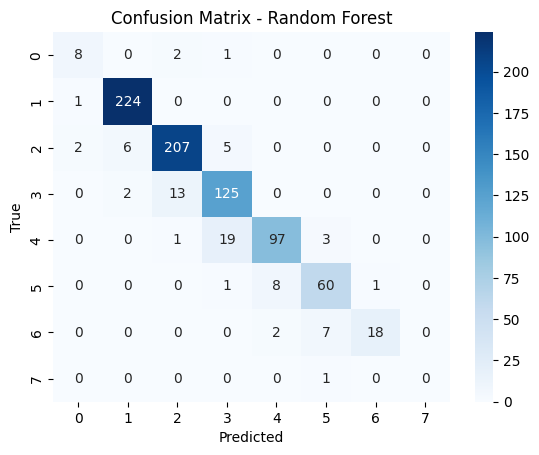

In [447]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Initialize Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
preds = rf_model.predict(X_test)

# Evaluation
print("Model: Random Forest")
print("Accuracy:", accuracy_score(y_test, preds))
print("F1 Score:", f1_score(y_test, preds, average='weighted'))
print("Classification Report:\n", classification_report(y_test, preds))

# Confusion matrix
cm = confusion_matrix(y_test, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


### Regressor model

Model: XGBoost Regressor
R² Score: 0.9557297229766846
Mean Squared Error (MSE): 0.09357399090506052
Mean Absolute Error (MAE): 0.16872693616576512


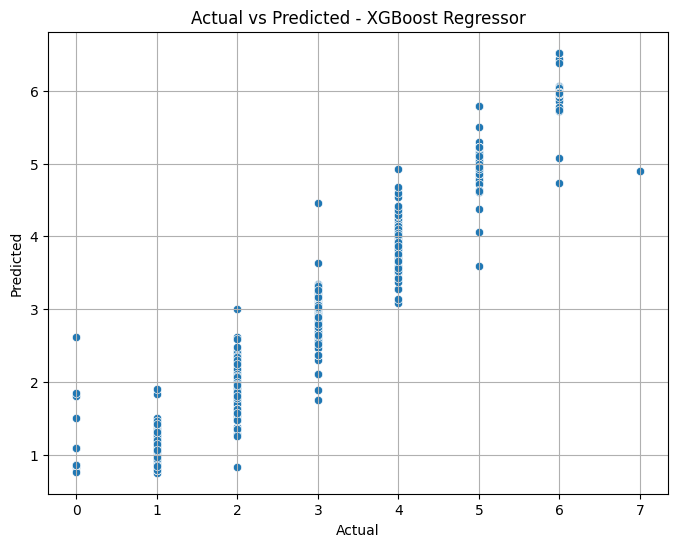

In [449]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBRegressor

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Initialize and train XGBoost Regressor
xgb_regressor = XGBRegressor(random_state=42)
xgb_regressor.fit(X_train, y_train)

# Predict
preds = xgb_regressor.predict(X_test)

# Evaluation
print("Model: XGBoost Regressor")
print("R² Score:", r2_score(y_test, preds))
print("Mean Squared Error (MSE):", mean_squared_error(y_test, preds))
print("Mean Absolute Error (MAE):", mean_absolute_error(y_test, preds))

# Plot actual vs predicted
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=preds)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted - XGBoost Regressor')
plt.grid(True)
plt.show()


### Saving model

In [451]:
# Ensure target is numeric and drop rows with NaN target
ml_df = ml_df.dropna(subset=["infection complexity arkscore"])
ml_df["infection complexity arkscore"] = ml_df["infection complexity arkscore"].astype(int)

# Update features and target
features = ml_df[organism_names + resistance_names].fillna(0)
target = ml_df["infection complexity arkscore"]


### Saving required data

In [453]:
import os
import joblib
import pandas as pd
from xgboost import XGBRegressor

# Folder setup
output_dir = "infection_complexity_arkscore_model"
os.makedirs(output_dir, exist_ok=True)

# Clean and prepare the data
ml_df = ml_df.dropna(subset=["infection complexity arkscore"])
ml_df["infection complexity arkscore"] = ml_df["infection complexity arkscore"].astype(int)

features = ml_df[organism_names + resistance_names].fillna(0)
target = ml_df["infection complexity arkscore"]

# Train XGBoost Regressor
xgb_regressor = XGBRegressor(random_state=42)
xgb_regressor.fit(features, target)

# Save model
joblib.dump(xgb_regressor, os.path.join(output_dir, "xgboost_regressor_infection_complexity_arkscore.pkl"))

# Save data
features.to_csv(os.path.join(output_dir, "features.csv"), index=False)
target.to_csv(os.path.join(output_dir, "target.csv"), index=False, header=True)
ml_df.to_csv(os.path.join(output_dir, "ml_df_full.csv"), index=False)

# Save feature columns
joblib.dump(features.columns.tolist(), os.path.join(output_dir, "feature_columns.pkl"))

print(f"All model and data files saved in: {output_dir}")


All model and data files saved in: infection_complexity_arkscore_model


### Predictions

In [455]:
features.columns

Index(['escherichia coli', 'enterococcus faecalis', 'citrobacter koseri',
       'enterobacter cloacae', 'klebsiella oxytoca', 'klebsiella pneumoniae',
       'aerococcus urinae', 'pseudomonas aeruginosa',
       'acinetobacter baumannii', 'corynebacterium riegelii',
       'staphylococcus aureus', 'candida albicans', 'streptococcus agalactiae',
       'proteus mirabilis', 'candida glabrata', 'enterococcus faecium',
       'providencia stuartii', 'citrobacter amalonaticus',
       'enterobacter aerogenes', 'staphylococcus lugdunensis',
       'serratia marcescens', 'staphylococcus saprophyticus',
       'streptococcus oralis', 'staphylococcus epidermidis',
       'staphylococcus haemolyticus', 'streptococcus pasteuranus',
       'trichomonas vaginalis', 'enterococcus spp', 'proteus spp',
       'morganella morganii', 'klebsiella aerogenes', 'anaerococcus spp',
       'citrobacter spp', 'neisseria gonorrhoea', 'candida krusei',
       'candida spp', 'chlamydia trachomatis', 'mycoplasma 

In [ ]:
df_3["infection complexity arkscore"]

In [469]:
from docx import Document

# Create a Word document
doc = Document()

# Add title
doc.add_heading("📘 Infection Complexity Arkscore Predictor – Documentation", 0)

# Add overview section
doc.add_heading("🔍 Overview", level=1)
doc.add_paragraph(
    "This script uses a trained **XGBoost regression model** to predict the **Infection Complexity Arkscore** "
    "from microbiological organism and resistance profile data. It supports both **interactive user input** "
    "and **automated prediction from a file (CSV/JSON)**."
)

# Add function description section
doc.add_heading("🧠 Function: `predict_infection_complexity`", level=1)
doc.add_heading("📌 Description:", level=2)
doc.add_paragraph(
    "Predicts infection complexity arkscore based on microbiological test features. Accepts feature values directly "
    "as a dictionary or collects them interactively if not provided."
)

doc.add_heading("📥 Parameters:", level=2)
doc.add_paragraph(
    "* **`input_features`** *(dict, optional)*:\n"
    "  Dictionary with feature names as keys and their corresponding float/int values.\n"
    "  If `None`, the function prompts user input for each feature.\n\n"
    "* **`model_dir`** *(str, default=`\"infection_complexity_arkscore_model\"`)*:\n"
    "  Directory path containing the trained model and feature list files:\n"
    "  * `xgboost_regressor_infection_complexity_arkscore.pkl`\n"
    "  * `feature_columns.pkl`"
)

doc.add_heading("📤 Returns:", level=2)
doc.add_paragraph(
    "* **`float`**: Predicted infection complexity arkscore (rounded to 2 decimal places)"
)

# Add example usage section
doc.add_heading("🧪 Example Use (Python Script)", level=1)
doc.add_paragraph("""
from predictor import predict_infection_complexity

# Predict using dictionary of known features
input_dict = {
    "escherichia coli": 3.5,
    "klebsiella pneumoniae": 1.2,
    "quinolone": 2.0
}
score = predict_infection_complexity(input_features=input_dict)
print("Predicted Score:", score)
""")

# Add command-line usage section
doc.add_heading("🖥️ Command Line Usage", level=1)

doc.add_heading("🔧 Required Files:", level=2)
doc.add_paragraph(
    "* Trained model: `infection_complexity_arkscore_model/xgboost_regressor_infection_complexity_arkscore.pkl`\n"
    "* Feature list: `infection_complexity_arkscore_model/feature_columns.pkl`"
)

doc.add_heading("▶️ Run:", level=2)
doc.add_paragraph("```bash\npython predictor.py input.csv\n```")

doc.add_heading("✅ Supported Input Formats:", level=2)
doc.add_paragraph(" * `.csv`\n * `.json`")

doc.add_heading("📂 Input File Format (CSV/JSON):", level=2)
doc.add_paragraph(
    "Must contain a **single row** with **feature names as columns**."
)

# Sample CSV input
doc.add_heading("📝 Sample CSV (`input.csv`):", level=3)
doc.add_paragraph("""
escherichia coli,klebsiella pneumoniae,quinolone,tmp-smx
3.5,1.2,2.0,0.5
""")

# Sample JSON input
doc.add_heading("📝 Sample JSON (`input.json`):", level=3)
doc.add_paragraph("""
[{
  "escherichia coli": 3.5,
  "klebsiella pneumoniae": 1.2,
  "quinolone": 2.0,
  "tmp-smx": 0.5
}]
""")

# Add output section
doc.add_heading("🎯 Output", level=1)
doc.add_paragraph(
    "The output is a **single float value** representing the predicted *infection complexity arkscore*.\n\n"
    "Example:\n\n"
    "```bash\nPredicted Infection Complexity Arkscore: 2.83\n```"
)

# Add notes section
doc.add_heading("🛠️ Notes", level=1)
doc.add_paragraph(
    "* Missing features in input default to **`0.0`**.\n"
    "* Invalid input (non-numeric) will be ignored with a warning and defaulted to **`0.0`**.\n"
    "* Model assumes feature values are **Ct values (quantitative)** from pathogen or resistance detection."
)

# Save the document
word_file_path = "C:/Users/gaura/Downloads/WTF (5)/infection_complexity_arkscore_model/Infection_Complexity_Arkscore_Documentation.docx"
doc.save(word_file_path)

word_file_path


'C:/Users/gaura/Downloads/WTF (5)/infection_complexity_arkscore_model/Infection_Complexity_Arkscore_Documentation.docx'